![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


## LO.1. Effective index of a waveguide

### 1.1. Materials

We need the refractive index of each material in the cross-section. There are different options to get this information, such as [RefractiveIndex.info](https://refractiveindex.info/) and the [Material Library from Tidy3D](https://docs.flexcompute.com/projects/tidy3d/en/v2.6.0/api/material_library.html#). Here we will load and check the characteristics from the most common materials used in fabrication of photonic circuits: **silicon (Si), silicon nitride (SiNx) and silicon dioxide (SiO2)**.

#### 1.1.1. Crystalline Silicon 

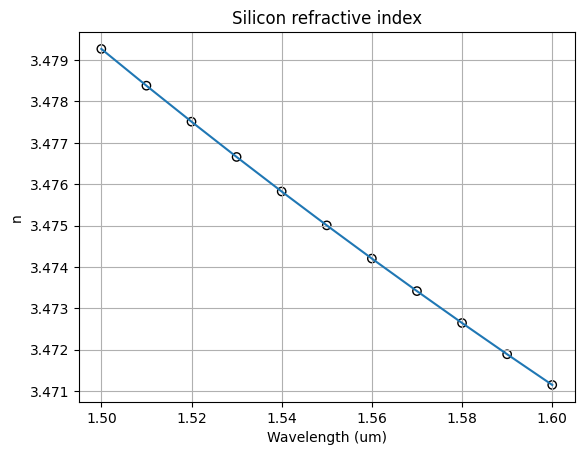

In [2]:
## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
## Check the Tidy3D Docs for more information on the "Variant"

## Index at a particular wavelength
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
plt.scatter(wavelength, si_index,edgecolors='k',facecolors='none')
plt.plot(wavelength,si_index)
plt.title("Silicon refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

#### 1.1.2. Silicon Nitride

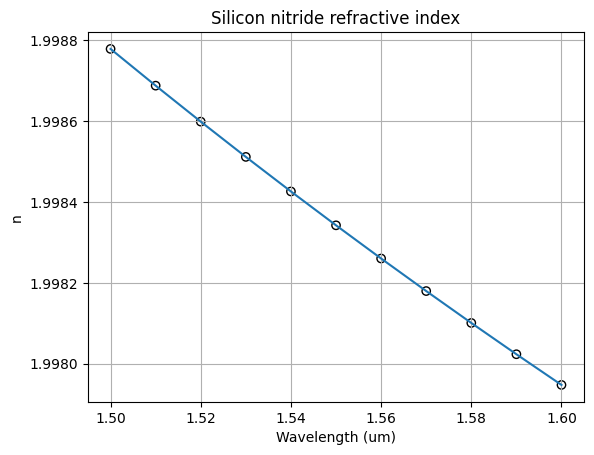

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
plt.scatter(wavelength,nitride_index,edgecolors='k',facecolors='none')
plt.plot(wavelength, nitride_index)
plt.title("Silicon nitride refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()


#### 1.1.3. Silicon Dioxide

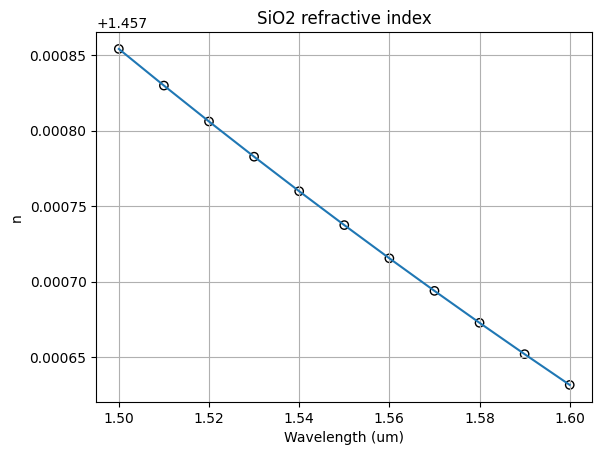

In [4]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.scatter(wavelength,box_index,edgecolors='k',facecolors='None')
plt.plot(wavelength, box_index)
plt.title("SiO2 refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

### 1.2. Cross - Section Definition

In GDSFactory - Tidy3d modesolver we just have to use the [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. 
It implements the **deep (rib)** and **shallow (ridge)** waveguide variants. The following example corresponds to a **deep** waveguide for the **silicon nitride** fabrication proccess, this means that the **cladding** material is silicon dioxide and the **core** material is silicon nitride. The waveguide dimensions are 300 nm (height) and 1.2 um (width). We will check it's behavior at 1.55 um. 

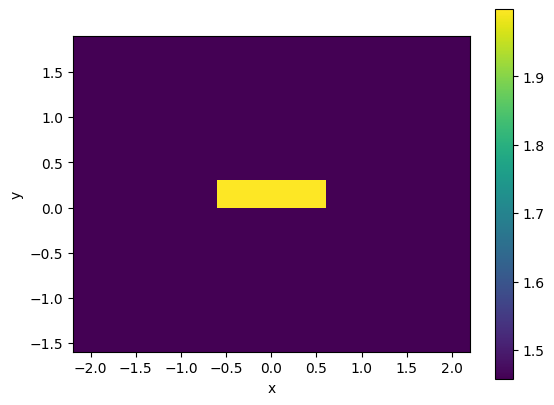

In [5]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

### 1.3. Simulations

#### 1.3.1. Numerical results

We can find the effective index (n_eff), TE and TM fraction for each particular cross-section.

In [8]:
deep_waveguide.n_eff

array([1.60524792+0.00010066j, 1.52829803+0.00017753j,
       1.45072999+0.00019228j, 1.43325817+0.00021838j])

In [43]:
deep_waveguide.fraction_te

array([0.99505426, 0.01004259, 0.96264794, 0.047651  ])

In [44]:
deep_waveguide.fraction_tm

array([0.00494574, 0.98995741, 0.03735206, 0.952349  ])

#### 1.3.4. Plots

Text(0.5, 1.0, 'TE00')

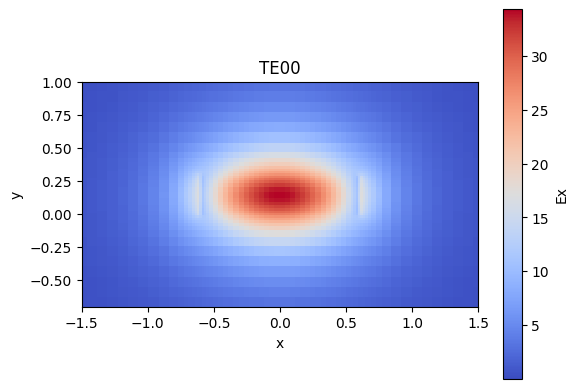

In [8]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('TE00') # You might need this later :) 

Text(0.5, 1.0, 'TM00')

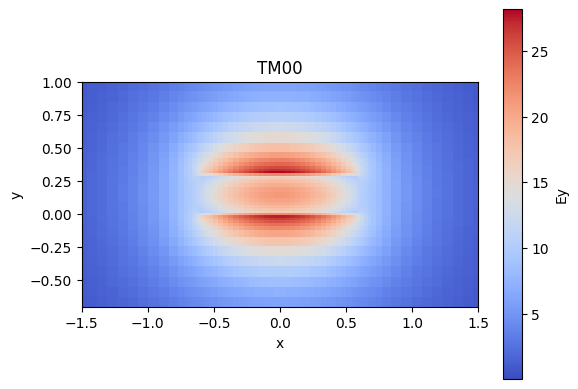

In [9]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title('TM00')

Text(0.5, 1.0, 'TE10')

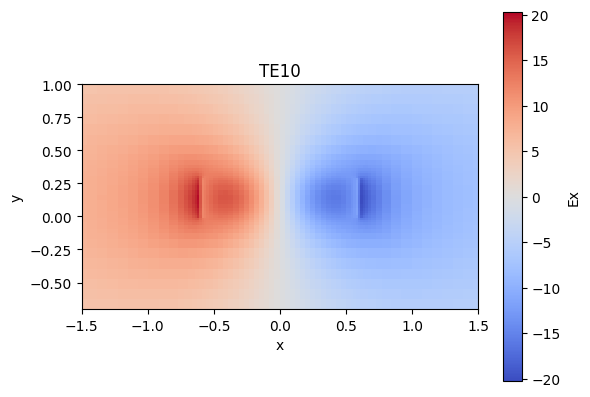

In [10]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title('TE10')

Text(0.5, 1.0, 'TM10')

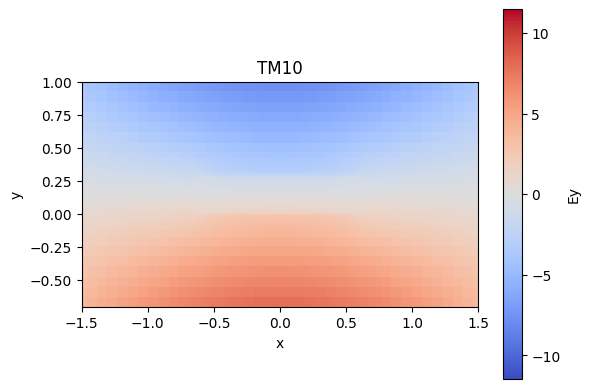

In [11]:
deep_waveguide.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
plt.title('TM10')

**Important** 
These results are derived from a numerical method used to solve the EM problem, so they must always be interpreted carefully to assess their accuracy. You must check, for instance, if the value of each index neff is higher than the refractive index of the cladding. 

## LO.2. Wavelength behavior

- Let's find the wavelength dependence of the effective index of the SiNx deep waveguide described in LO1. Change the wavelength used at the waveguide cross-section function, it could be a vector also. 

2026-02-20 20:34:11.198 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.


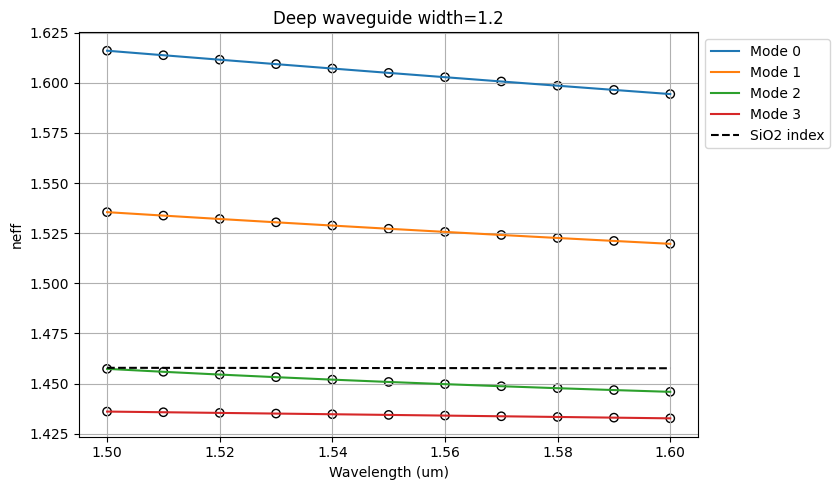

In [13]:
# The wavelength could be a vector also
# Student code here. Tip np.linspace()
wavelength = np.linspace(1.5, 1.6,11) 


deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

- Repeat the analysis for a **shallow**ly etched waveguide with a 150 nm slab heigth. 

2026-02-17 13:49:17.946 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf0af488213d9e23.npz.


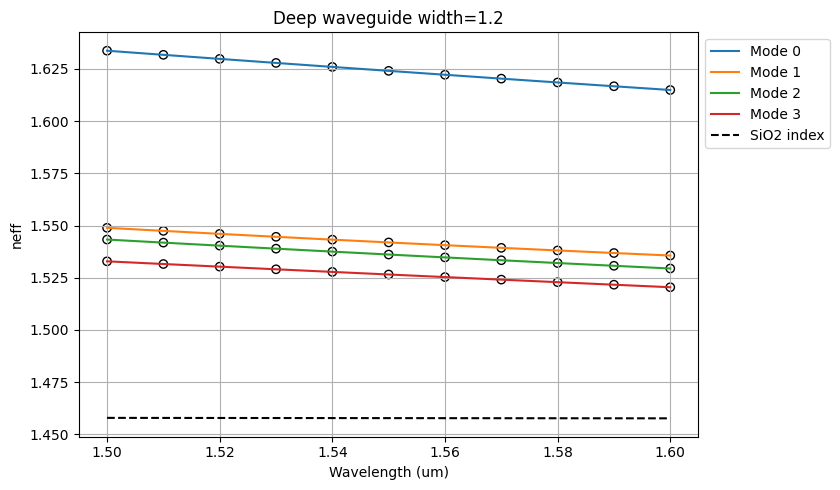

In [ ]:
wavelength = np.linspace(1.5, 1.6,11) 


deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=150 * nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

## LO.3. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/11 [00:00<?, ?it/s]

2026-02-21 00:49:11.352 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-02-21 00:49:11.358 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-02-21 00:49:11.362 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_575965d134f345c4.npz.
2026-02-21 00:49:11.375 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3ca61e62fe85ccf2.npz.


2026-02-21 00:49:11.377 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b617c8aef408673.npz.
2026-02-21 00:49:11.396 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd84020834745298.npz.
2026-02-21 00:49:11.411 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_df7667b1ace5cc7e.npz.
2026-02-21 00:49:11.420 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a4e198a34f8f1987.npz.
2026-02-21 00:49:11.426 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1cba93ec3f707c97.npz.
2026-02-21 00:49:11.441 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_495965be167ef02f.npz.
2026-02-21 00:49:11.445 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_415c86fe948629a6.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-02-21 00:49:11.492 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-02-21 00:49:11.497 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-02-21 00:49:11.508 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_575965d134f345c4.npz.
2026-02-21 00:49:11.524 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3ca61e62fe85ccf2.npz.
2026-02-21 00:49:11.529 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b617c8aef408673.npz.
2026-02-21 00:49:11.548 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd84020834745298.npz.
2026-02-21 00:49:11.552 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_df7667b1ace5cc7e.npz.
2026-02-21 00:49:11.592 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a4e198a34f8f1987.npz.


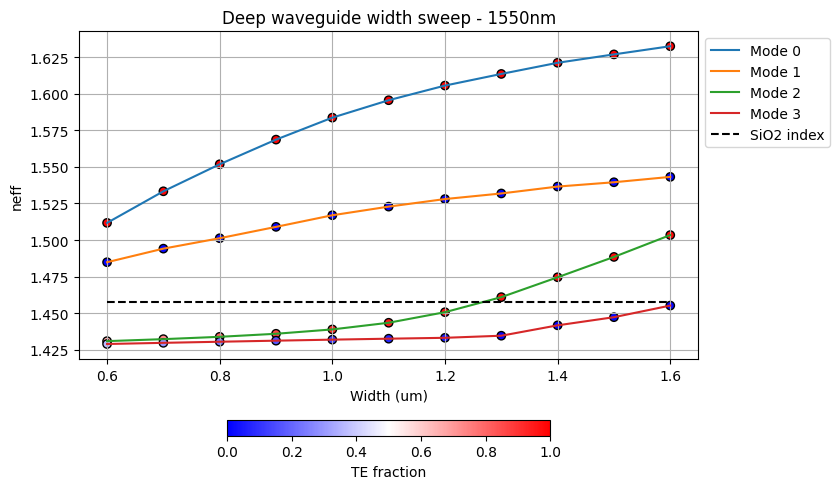

In [15]:
wavelength = 1.55

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.6, 1.6,11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.4. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Consider: 

The transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\gamma(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\gamma(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\gamma(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda) = \mathrm{Re}\{\gamma(\lambda)\}\,z
= \frac{2\pi}{\lambda}\,n_\mathrm{eff}(\lambda).
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the values for n, ng and D of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

DEEP WAVEGUIDE (height=300nm, width=1.2um, slab=0nm)
2026-02-24 13:43:01.551 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.
n1 (neff at λ0=1.55um): 1.604917
n2: -2.161769e-01
n3: 9.735507e-02
ng (group index): 1.939991
D (dispersion): -1.006002e-03 s²/m
n1 (neff at λ0=1.55um): 1.527189
n2: -1.579588e-01
n3: 1.538317e-01
ng (group index): 1.772025
D (dispersion): -1.589594e-03 s²/m


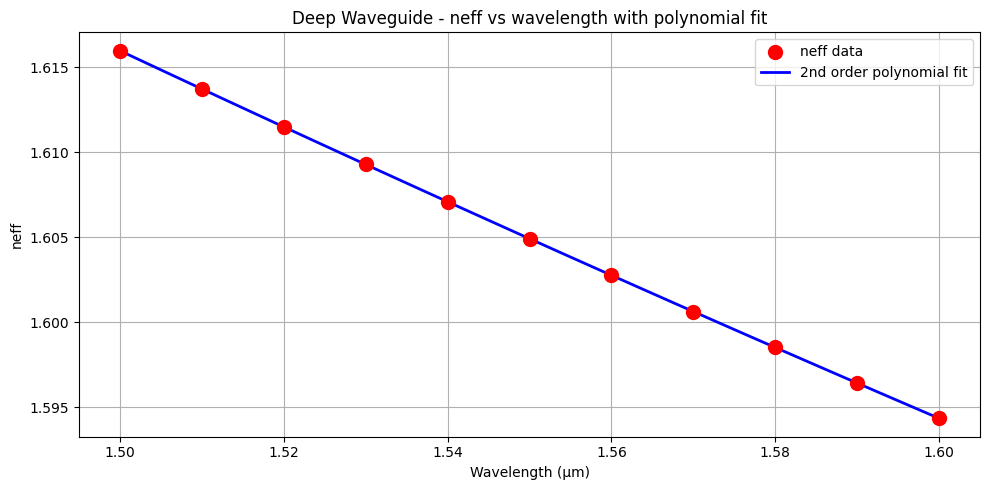

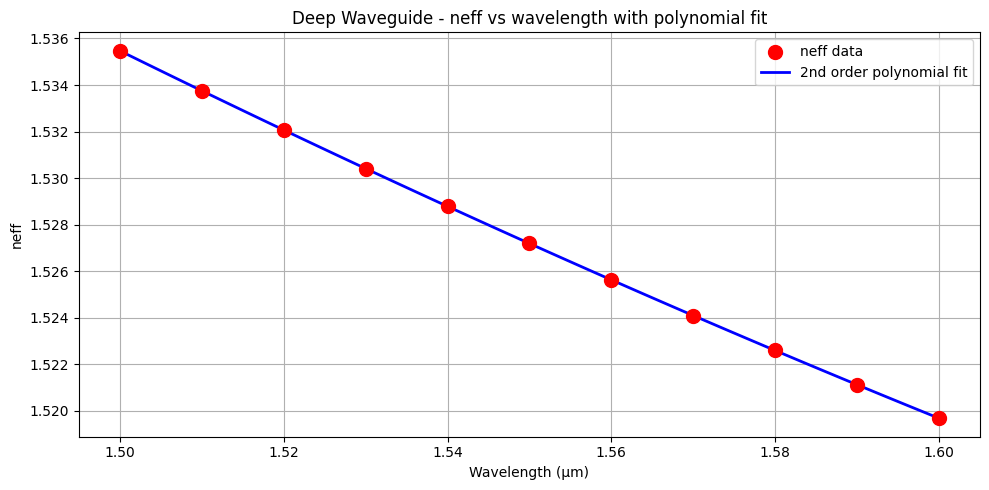


SHALLOW WAVEGUIDE (height=300nm, width=1.2um, slab=150nm)
2026-02-24 13:43:02.290 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf0af488213d9e23.npz.
n1 (neff at λ0=1.55um): 1.624091
n2: -1.881749e-01
n3: 9.569580e-02
ng (group index): 1.915762
D (dispersion): -9.888566e-04 s²/m


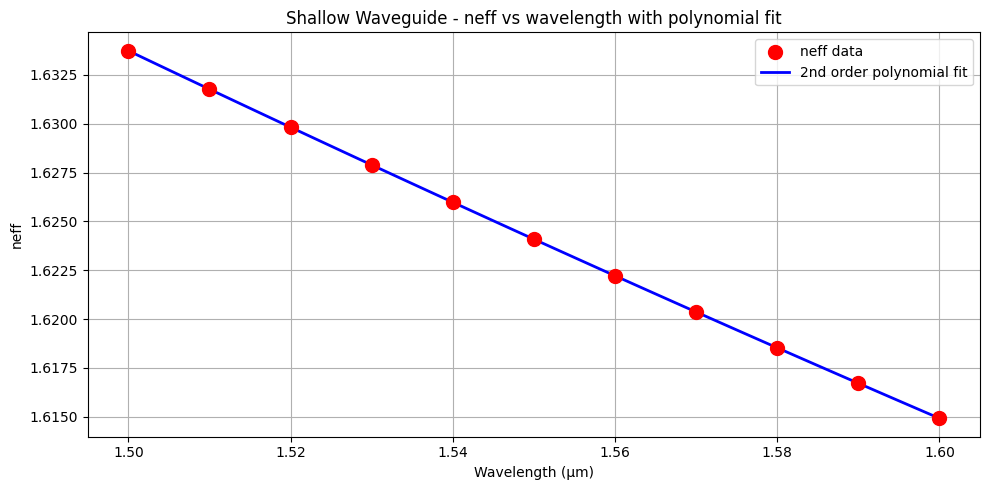


SUMMARY
Parameter            Deep WG              Shallow WG          
------------------------------------------------------------
n1 (neff @ 1.55μm)   1.604917             1.624091            
ng (group index)     1.939991             1.915762            
D (s²/m)             -1.006002e-03        -9.888566e-04       


In [ ]:
# STUDENT! Put your code here.

# Reference wavelength (nm)
lambda_0 = 1.55  # micras

# 1. DEEP WAVEGUIDE (slab_thickness = 0.0)
#print("="*60)
print("DEEP WAVEGUIDE (height=300nm, width=1.2um, slab=0nm)")
#print("="*60)

# Create waveguide with wavelength sweep
wavelength_deep = np.linspace(1.5, 1.6, 11)
deep_wg = gt.modes.Waveguide(
    wavelength=wavelength_deep,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

# Get neff for fundamental mode (mode 0)
neff_deep = deep_wg.n_eff[:, 0].real
neff_deep_tm = deep_wg.n_eff[:,1].real #

# Fit polynomial: n_eff(λ) = n1 + n2*(λ - λ0) + n3*(λ - λ0)^2
delta_lambda_deep = wavelength_deep - lambda_0
coeffs_deep = np.polyfit(delta_lambda_deep, neff_deep, 2)
coeffs_deep_tm = np.polyfit(delta_lambda_deep, neff_deep_tm, 2)#
n3_deep, n2_deep, n1_deep = coeffs_deep
n3_deep_tm, n2_deep_tm, n1_deep_tm = coeffs_deep_tm #

# Calculate ng (group index) and D (dispersion)
ng_deep = n1_deep - n2_deep * lambda_0
ng_deep_tm = n1_deep_tm - n2_deep_tm * lambda_0
c = 3e8 * 1e-6  # Speed of light in um/s
D_deep = -2 * lambda_0 * n3_deep / c
D_deep_tm = -2 * lambda_0 * n3_deep_tm / c

#Para modo TE
print(f"n1 (neff at λ0={lambda_0}um): {n1_deep:.6f}")
print(f"n2: {n2_deep:.6e}")
print(f"n3: {n3_deep:.6e}")
print(f"ng (group index): {ng_deep:.6f}")
print(f"D (dispersion): {D_deep:.6e} s²/m")


#Para modo TM
print(f"n1 (neff at λ0={lambda_0}um): {n1_deep_tm:.6f}")
print(f"n2: {n2_deep_tm:.6e}")
print(f"n3: {n3_deep_tm:.6e}")
print(f"ng (group index): {ng_deep_tm:.6f}")
print(f"D (dispersion): {D_deep_tm:.6e} s²/m")

# Plot the fit modo TE
plt.figure(figsize=(10, 5))
plt.scatter(wavelength_deep, neff_deep, color='red', s=100, label='neff data', zorder=5)
lambda_fit = np.linspace(wavelength_deep.min(), wavelength_deep.max(), 100)
delta_lambda_fit = lambda_fit - lambda_0
neff_fit = np.polyval(coeffs_deep, delta_lambda_fit)
plt.plot(lambda_fit, neff_fit, 'b-', linewidth=2, label='2nd order polynomial fit')
plt.xlabel('Wavelength (μm)')
plt.ylabel('neff')
plt.title('Deep Waveguide - neff vs wavelength with polynomial fit')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plot the fit modo TM
plt.figure(figsize=(10, 5))
plt.scatter(wavelength_deep, neff_deep_tm, color='red', s=100, label='neff data', zorder=5)
lambda_fit = np.linspace(wavelength_deep.min(), wavelength_deep.max(), 100)
delta_lambda_fit = lambda_fit - lambda_0
neff_fit = np.polyval(coeffs_deep_tm, delta_lambda_fit)
plt.plot(lambda_fit, neff_fit, 'b-', linewidth=2, label='2nd order polynomial fit')
plt.xlabel('Wavelength (μm)')
plt.ylabel('neff')
plt.title('Deep Waveguide - neff vs wavelength with polynomial fit')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


# 2. SHALLOW WAVEGUIDE (slab_thickness = 150nm)
print("\n" + "="*60)
print("SHALLOW WAVEGUIDE (height=300nm, width=1.2um, slab=150nm)")
print("="*60)

wavelength_shallow = np.linspace(1.5, 1.6, 11)
shallow_wg = gt.modes.Waveguide(
    wavelength=wavelength_shallow,
    core_width=1.2,
    slab_thickness=150 * nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

# Get neff for fundamental mode (mode 0)
neff_shallow = shallow_wg.n_eff[:, 0].real

# Fit polynomial: n_eff(λ) = n1 + n2*(λ - λ0) + n3*(λ - λ0)^2
delta_lambda_shallow = wavelength_shallow - lambda_0
coeffs_shallow = np.polyfit(delta_lambda_shallow, neff_shallow, 2)
n3_shallow, n2_shallow, n1_shallow = coeffs_shallow

# Calculate ng (group index) and D (dispersion)
ng_shallow = n1_shallow - n2_shallow * lambda_0
D_shallow = -2 * lambda_0 * n3_shallow / c

print(f"n1 (neff at λ0={lambda_0}um): {n1_shallow:.6f}")
print(f"n2: {n2_shallow:.6e}")
print(f"n3: {n3_shallow:.6e}")
print(f"ng (group index): {ng_shallow:.6f}")
print(f"D (dispersion): {D_shallow:.6e} s²/m")

# Plot the fit
plt.figure(figsize=(10, 5))
plt.scatter(wavelength_shallow, neff_shallow, color='red', s=100, label='neff data', zorder=5)
delta_lambda_fit = lambda_fit - lambda_0
neff_fit = np.polyval(coeffs_shallow, delta_lambda_fit)
plt.plot(lambda_fit, neff_fit, 'b-', linewidth=2, label='2nd order polynomial fit')
plt.xlabel('Wavelength (μm)')
plt.ylabel('neff')
plt.title('Shallow Waveguide - neff vs wavelength with polynomial fit')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"{'Parameter':<20} {'Deep WG':<20} {'Shallow WG':<20}")
print("-"*60)
print(f"{'n1 (neff @ 1.55μm)':<20} {n1_deep:<20.6f} {n1_shallow:<20.6f}")
print(f"{'ng (group index)':<20} {ng_deep:<20.6f} {ng_shallow:<20.6f}")
print(f"{'D (s²/m)':<20} {D_deep:<20.6e} {D_shallow:<20.6e}")

## LO.5. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

/home/javier/CIFOIN_PRACTICAS/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/javier/CIFOIN_PRACTICAS/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/javier/CIFOIN_PRACTICAS/cifoin-lab1/.venv/lib/python3

2026-02-21 14:07:24.672 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_1592dba1d8e935a8.npz.


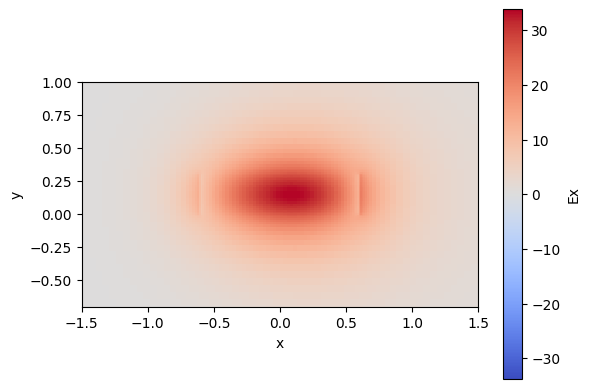

In [16]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/10 [00:00<?, ?it/s]

/home/javier/CIFOIN_PRACTICAS/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/javier/CIFOIN_PRACTICAS/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/javier/CIFOIN_PRACTICAS/cifoin-lab1/.venv/lib/python3

Text(0, 0.5, 'Mismatch (dB)')

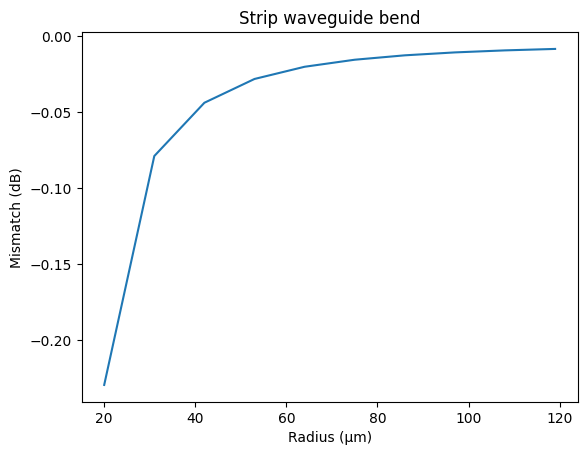

In [17]:
radii = np.arange(20.0, 120,11)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


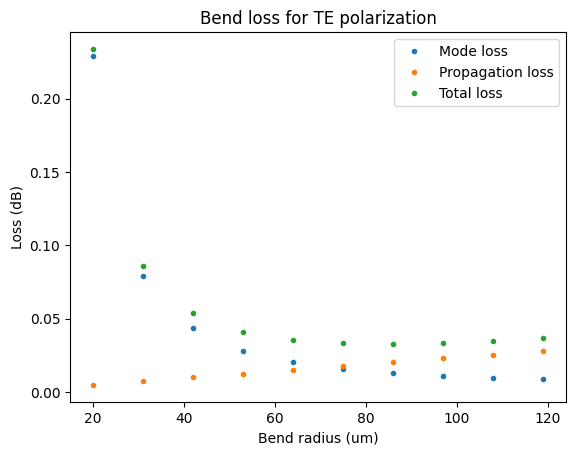

In [18]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. Consider safe means less than 0.1 dB/90º

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.2. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.3. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

SOI (Silicon-On-Insulator) Waveguide - Wavelength Range [1.5-1.6 um]2026-02-17 13:49:58.274 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_38091c594b211d32.npz.

Core: Si (220nm height), Width: 500nm



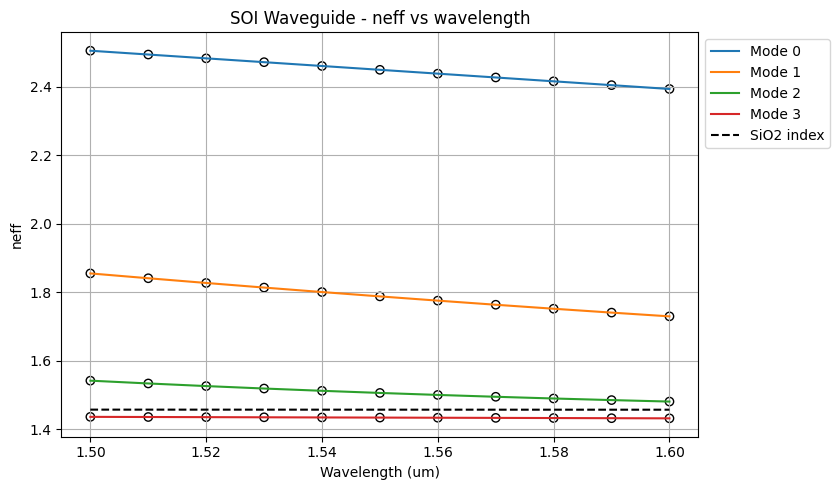

In [56]:
### EXTRA.1. SOI Wavelength behavior

# SOI waveguide parameters
# Height = 220nm, Width = 500nm, Core = Si, Cladding = SiO2

wavelength_soi = np.linspace(1.5, 1.6, 11)

soi_deep = gt.modes.Waveguide(
    wavelength=wavelength_soi,
    core_width=0.5,  # 500nm in um
    slab_thickness=0.0,  # Deep etched
    core_material='si',  # Silicon
    clad_material='sio2',
    core_thickness=220 * nm,  # 220nm height
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

neff_soi = soi_deep.n_eff
te_soi = soi_deep.fraction_te

print("SOI (Silicon-On-Insulator) Waveguide - Wavelength Range [1.5-1.6 um]")
print("Core: Si (220nm height), Width: 500nm")
print()

plt.figure(figsize=(10, 5))
for k in range(neff_soi.shape[1]):
    plt.scatter(wavelength_soi, neff_soi[:,k].real, edgecolors='k', facecolors='none', label='__nolegend__')
    plt.plot(wavelength_soi, neff_soi[:,k].real, label=f'Mode {k}')
plt.title("SOI Waveguide - neff vs wavelength")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength_soi, box_index, 'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Calculating SOI neff for different widths...
2026-02-17 13:49:58.564 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-02-17 13:49:58.576 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ce81d30082f5cfc5.npz.
2026-02-17 13:49:58.579 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-02-17 13:49:58.580 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_401cb9732cf25023.npz.
2026-02-17 13:49:58.582 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_31626027bb3dd9b4.npz.
2026-02-17 13:49:58.592 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24197408d3d2932f.npz.


2026-02-17 13:49:58.596 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2e78eba690755aa1.npz.
2026-02-17 13:49:58.599 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_07b520dc17f68bb3.npz.
2026-02-17 13:49:58.603 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-02-17 13:49:58.610 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ce81d30082f5cfc5.npz.
2026-02-17 13:49:58.615 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-02-17 13:49:58.620 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_401cb9732cf25023.npz.
2026-02-17 13:49:58.624 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_31626027bb3dd9b4.npz.
2026-02-17 13:49:58.626 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24197408d3d2932f.npz.


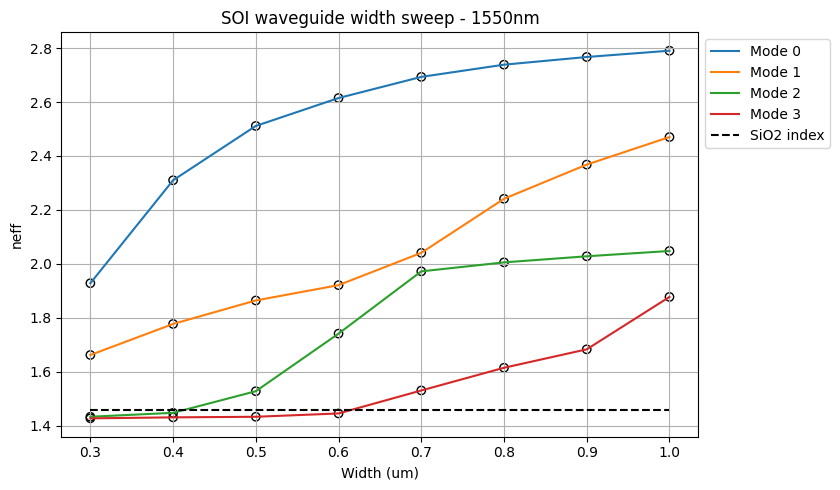

Width dependence calculated


In [57]:
### EXTRA.2. SOI Width dependence

# Sweep width from 300nm to 1um at fixed wavelength 1.55um

widths_soi = np.linspace(0.3, 1.0, 8)  # 300nm to 1um

neff_soi_width = []

print("Calculating SOI neff for different widths...")

for w in widths_soi:
    soi_w = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=w,
        slab_thickness=0.0,
        core_material='si',
        clad_material='sio2',
        core_thickness=220 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=20,
    )
    # For single wavelength, n_eff is 1D, so use it directly
    neff_soi_width.append(soi_w.n_eff)

neff_soi_width = np.array(neff_soi_width)

# Get TE fraction
soi_te = []
for w in widths_soi:
    soi_w_te = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=w,
        slab_thickness=0.0,
        core_material='si',
        clad_material='sio2',
        core_thickness=220 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=20,
    )
    soi_te.append(soi_w_te.fraction_te)

soi_te = np.array(soi_te)

plt.figure(figsize=(10, 5))
for k in range(neff_soi_width.shape[1]):
    plt.scatter(widths_soi, neff_soi_width[:,k].real, edgecolors='k', facecolors='none', label='__nolegend__')
    plt.plot(widths_soi, neff_soi_width[:,k].real, label=f'Mode {k}')
plt.title("SOI waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(widths_soi, box_index[0]*np.ones_like(widths_soi), 'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

print("Width dependence calculated")

Calculating SOI bend mismatch loss...


  0%|          | 0/6 [00:00<?, ?it/s]

/home/jorge/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jorge/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jorge/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

SOI parameters:
Material loss: 3.0 dB/cm



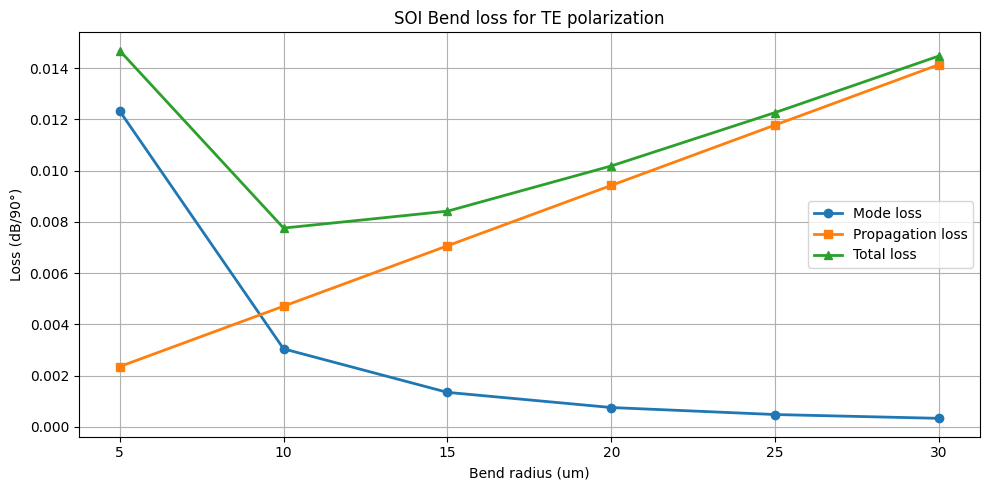


Safe radius (< 0.1 dB/90°): > 5.0 um


In [58]:
### EXTRA.3. SOI Bend loss analysis

# SOI bend analysis - radius 5 to 30um

# First, calculate bend mode at 1550nm
soi_bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=0.5,  # 500nm
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30,
    bend_radius=20,
)

# Calculate mode mismatch for different radii
radii_soi = np.arange(5.0, 35, 5)  # 5 to 30um range

print("Calculating SOI bend mismatch loss...")
mismatch_soi = gt.modes.sweep_bend_mismatch(soi_bend_1550, radii_soi)

# Propagation loss
dB_cm_soi = 3.0  # Higher loss for Si than SiNx (typical)
length_soi = 0.5 * np.pi * radii_soi * 1e-6
propagation_loss_soi = dB_cm_soi * length_soi * 1e2

print("SOI parameters:")
print(f"Material loss: {dB_cm_soi} dB/cm")
print()

plt.figure(figsize=(10, 5))
plt.title("SOI Bend loss for TE polarization")
plt.plot(radii_soi, -10 * np.log10(mismatch_soi), "o-", label="Mode loss", linewidth=2)
plt.plot(radii_soi, propagation_loss_soi, "s-", label="Propagation loss", linewidth=2)
plt.plot(radii_soi, propagation_loss_soi - 10 * np.log10(mismatch_soi), "^-", label="Total loss", linewidth=2)
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90°)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Find safe radius
safe_loss = 0.1
total_loss_soi = propagation_loss_soi - 10 * np.log10(mismatch_soi)
safe_radii_soi = radii_soi[total_loss_soi < safe_loss]

if len(safe_radii_soi) > 0:
    print(f"\nSafe radius (< 0.1 dB/90°): > {safe_radii_soi[0]} um")
else:
    print(f"\nNo radius in range is safe for < 0.1 dB/90°")
    print(f"Minimum loss achieved: {total_loss_soi.min():.4f} dB at {radii_soi[np.argmin(total_loss_soi)]:.1f} um")

COMPARISON: SiNx (Deep) vs SOI Technologies

SiNx Technology (Deep Etched)
----------------------------------------------------------------------
  Core material: Silicon Nitride (SiNx)
  Cladding: SiO2
  Dimensions: 300nm height × 1.2um width
  neff @ 1.55um (Mode 0): 1.604917
  Group index (ng): 1.939991
  Dispersion (D): -1.006002e-03 s²/m

SOI Technology (Deep Etched)
----------------------------------------------------------------------
  Core material: Silicon (Si)
  Cladding: SiO2
  Dimensions: 220nm height × 500nm width
  neff @ 1.55um (Mode 0): 2.511347
  Material loss typical: ~3 dB/cm

Key Differences:
----------------------------------------------------------------------
Property                       SiNx                 SOI                 
----------------------------------------------------------------------
Refractive index               Lower (1.6-1.65)     Higher (3.4+)       
Mode confinement               Moderate             Very high           
Bend loss         

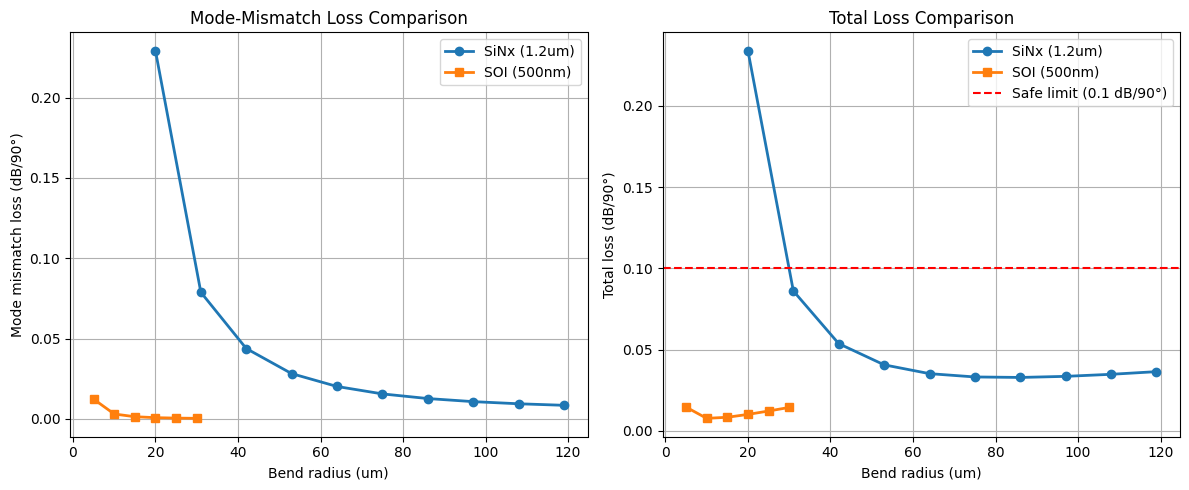

Conclusions:
----------------------------------------------------------------------
• SiNx: Better for low-loss, broad-wavelength applications
• SOI: Better for integrated circuits, high-density integration
• SiNx requires larger bend radii to maintain low loss
• SOI shows higher material absorption (Si properties)


In [59]:
### EXTRA.4. Technology comparison - SiNx vs SOI

print("="*70)
print("COMPARISON: SiNx (Deep) vs SOI Technologies")
print("="*70)
print()

# SiNx parameters (from LO sections)
print("SiNx Technology (Deep Etched)")
print("-" * 70)
print(f"  Core material: Silicon Nitride (SiNx)")
print(f"  Cladding: SiO2")
print(f"  Dimensions: 300nm height × 1.2um width")
print(f"  neff @ 1.55um (Mode 0): {neff_deep[5]:.6f}")  # approx middle wavelength
print(f"  Group index (ng): {ng_deep:.6f}")
print(f"  Dispersion (D): {D_deep:.6e} s²/m")
print()

# SOI parameters
print("SOI Technology (Deep Etched)")
print("-" * 70)
print(f"  Core material: Silicon (Si)")
print(f"  Cladding: SiO2")
print(f"  Dimensions: 220nm height × 500nm width")
neff_soi_1550 = neff_soi_width[np.argmin(np.abs(widths_soi - 0.5)), 0].real  # Get neff for 500nm width
print(f"  neff @ 1.55um (Mode 0): {neff_soi_1550:.6f}")
print(f"  Material loss typical: ~3 dB/cm")
print()

# Comparison table
print("Key Differences:")
print("-" * 70)
print(f"{'Property':<30} {'SiNx':<20} {'SOI':<20}")
print("-" * 70)
print(f"{'Refractive index':<30} {'Lower (1.6-1.65)':<20} {'Higher (3.4+)':<20}")
print(f"{'Mode confinement':<30} {'Moderate':<20} {'Very high':<20}")
print(f"{'Bend loss':<30} {'Lower':<20} {'Higher':<20}")
print(f"{'Propagation loss':<30} {'Lower (~1.5 dB/cm)':<20} {'Higher (~3 dB/cm)':<20}")
print(f"{'Wavelength range':<30} {'Broad (0.4-4um)':<20} {'Narrow (1.3-1.6um)':<20}")
print(f"{'Fabrication maturity':<30} {'Established':<20} {'Very mature':<20}")
print()

# Visual comparison of bend loss
plt.figure(figsize=(12, 5))

# Plot 1: Mode loss comparison
plt.subplot(1, 2, 1)
plt.plot(radii, -10 * np.log10(mismatch), "o-", label="SiNx (1.2um)", linewidth=2)
plt.plot(radii_soi, -10 * np.log10(mismatch_soi), "s-", label="SOI (500nm)", linewidth=2)
plt.xlabel("Bend radius (um)")
plt.ylabel("Mode mismatch loss (dB/90°)")
plt.title("Mode-Mismatch Loss Comparison")
plt.grid()
plt.legend()

# Plot 2: Total loss comparison
plt.subplot(1, 2, 2)
total_loss_sinx = propagation_loss - 10 * np.log10(mismatch)
total_loss_soi = propagation_loss_soi - 10 * np.log10(mismatch_soi)
plt.plot(radii, total_loss_sinx, "o-", label="SiNx (1.2um)", linewidth=2)
plt.plot(radii_soi, total_loss_soi, "s-", label="SOI (500nm)", linewidth=2)
plt.axhline(y=0.1, color='r', linestyle='--', label='Safe limit (0.1 dB/90°)')
plt.xlabel("Bend radius (um)")
plt.ylabel("Total loss (dB/90°)")
plt.title("Total Loss Comparison")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

print("="*70)
print("Conclusions:")
print("-" * 70)
print("• SiNx: Better for low-loss, broad-wavelength applications")
print("• SOI: Better for integrated circuits, high-density integration")
print("• SiNx requires larger bend radii to maintain low loss")
print("• SOI shows higher material absorption (Si properties)")
print("="*70)

## Grading

LO.1. 1 Point <br> 
LO.2. 2 Points <br> 
LO.3. 1 Point <br> 
LO.4. 2 Points <br> 
LO.5. 1 Point <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
